# Deep Hedging: From Rules to Learned Risk Controls
**Docker image**: `ml4t-gpu`

**Chapter 19: Quantitative Risk Management**
**Section Reference**: Section 19.7 (Adaptive Risk Controls)

## Purpose
This notebook demonstrates deep hedging (Buehler et al., 2019): a neural network learns
hedging positions that minimize CVaR of terminal PnL under transaction costs. Where
Section 19.7 builds adaptive risk controls from rules (vol targeting, regime caps, stops),
this notebook shows how the *same risk objective* can be optimized end-to-end by a neural
network — bridging the gap between measurement (Section 19.3) and learned control.

## Learning Objectives
After completing this notebook, you will be able to:
- Simulate GBM paths and compute Black-Scholes delta as a rule-based benchmark
- Build a semi-recurrent neural network that outputs hedging positions
- Train the hedger using CVaR as a differentiable loss function
- Compare learned hedging to delta hedging under transaction costs
- Analyze how the network discovers no-transaction bands

## Prerequisites
- Familiarity with option payoffs and Black-Scholes delta hedging
- Prior exposure to CVaR from Section 19.3
- A working PyTorch installation with enough memory for the simulation defaults

## Cross-References
- **Upstream**: VaR/CVaR measurement (Section 19.3, [`01_var_cvar`](01_var_cvar.ipynb))
- **This chapter**: Adaptive controls (Section 19.7), SHAP diagnostics ([`05_trade_shap_diagnostics`](05_trade_shap_diagnostics.ipynb))
- **Downstream**: Full RL treatment (Chapter 21), production integration ([`10_ml4t_backtest_risk_demo`](10_ml4t_backtest_risk_demo.ipynb))
- **Reference**: Buehler et al. (2019), "Deep Hedging"

## Setup

In [1]:
"""Deep Hedging — learn hedging positions that minimize CVaR of terminal PnL under transaction costs."""

import json
import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from plotly.subplots import make_subplots
from scipy.stats import norm

from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
# Production defaults
N_PATHS = 50_000
N_STEPS = 30
S0 = 100.0
STRIKE = 100.0
MU = 0.05
SIGMA = 0.20
R = 0.0
DT = 1 / 252
COST_RATE = 0.001
CVAR_ALPHA = 0.05
HIDDEN_SIZE = 32
N_EPOCHS = 100
LR = 5e-3
BATCH_SIZE = 2048
SEED = 42
FORCE_RETRAIN = False
COST_SWEEP_EPOCHS = 10
COST_SWEEP_MAX_TRAIN_PATHS = 10_000

In [3]:
OUTPUT_DIR = get_output_dir(19, "deep_hedging")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
set_global_seeds(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

CACHE_NPZ = OUTPUT_DIR / "deep_hedging_cache_v2.npz"
CACHE_JSON = OUTPUT_DIR / "deep_hedging_cache_v2.json"

Device: cuda


## The Hedging Problem

Section 19.7 presented rule-based adaptive controls: volatility targeting scales
positions by estimated vol, regime caps reduce exposure in stress, and stop-losses
exit at predefined thresholds. Each rule encodes human judgment about how positions
should respond to market conditions.

Deep hedging asks: what if we optimize the position-adjustment function *directly*?
Instead of designing rules, we define an objective — minimize CVaR of terminal PnL —
and let a neural network learn the mapping from market information to positions.

### Formalization

A market maker sells a European call option, receiving premium $p_0$, and hedges by
trading the underlying at discrete times $t_0, \ldots, t_{n-1}$. The terminal PnL is:

$$PL_T = p_0 - Z + \sum_{k=0}^{n-1} \delta_k (S_{k+1} - S_k) - C_T(\delta)$$

where $Z = \max(S_T - K, 0)$ is the option payoff, $\delta_k$ is the hedge position,
and $C_T(\delta)$ captures cumulative transaction costs. Perfect hedging ($PL_T = 0$
for all paths) is impossible under discrete rebalancing and costs. The goal is to find
positions $\delta_k$ that make the PnL distribution as tight as possible, especially
in the left tail.

### Simulate GBM Paths

In [5]:
def simulate_gbm_paths(s0, mu, sigma, n_paths, n_steps, dt, seed=None):
    """Simulate geometric Brownian motion price paths.

    Returns tensor of shape (n_paths, n_steps + 1).
    """
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(size=(n_paths, n_steps)).astype(np.float32)

    drift = (mu - 0.5 * sigma**2) * dt
    vol = sigma * np.sqrt(dt)

    log_returns = drift + vol * z
    log_prices = np.concatenate(
        [np.zeros((n_paths, 1), dtype=np.float32), np.cumsum(log_returns, axis=1)],
        axis=1,
    )
    return torch.tensor(s0 * np.exp(log_prices), device=device)

In [6]:
paths = simulate_gbm_paths(S0, MU, SIGMA, N_PATHS, N_STEPS, DT, seed=SEED)
print(f"Simulated {N_PATHS:,} paths, {N_STEPS} steps: shape {tuple(paths.shape)}")

Simulated 50,000 paths, 30 steps: shape (50000, 31)


### Black-Scholes Pricing and Delta

In [7]:
def bs_price_delta(spot, strike, tau, sigma, r=0.0):
    """Vectorized Black-Scholes call price and delta.

    All inputs are numpy arrays or scalars. Returns (price, delta) as numpy arrays.
    """
    spot = np.asarray(spot, dtype=np.float64)
    tau = np.asarray(tau, dtype=np.float64)

    eps = 1e-12
    sqrt_tau = np.sqrt(np.maximum(tau, eps))
    d1 = (np.log(np.maximum(spot, eps) / strike) + (r + 0.5 * sigma**2) * tau) / (
        sigma * sqrt_tau + eps
    )
    d2 = d1 - sigma * sqrt_tau

    price = spot * norm.cdf(d1) - strike * np.exp(-r * tau) * norm.cdf(d2)
    delta = norm.cdf(d1)

    return price.astype(np.float32), delta.astype(np.float32)

Compute Black-Scholes delta at each rebalancing date for all paths.

In [8]:
# Time to maturity at each step (decreasing)
tau_grid = np.array([(N_STEPS - k) * DT for k in range(N_STEPS)], dtype=np.float32)

# BS delta for each path and step: shape (n_paths, n_steps)
spot_np = paths[:, :-1].cpu().numpy()
tau_broadcast = np.broadcast_to(tau_grid, spot_np.shape)
_, bs_delta = bs_price_delta(spot_np, STRIKE, tau_broadcast, SIGMA, R)
bs_delta_t = torch.tensor(bs_delta, device=device)

# Option premium (BS price at t=0)
premium_scalar, _ = bs_price_delta(S0, STRIKE, N_STEPS * DT, SIGMA, R)
premium = torch.full((N_PATHS,), float(premium_scalar), device=device)

print(f"BS premium (t=0): {premium_scalar:.4f}")
print(f"BS delta range: [{bs_delta.min():.4f}, {bs_delta.max():.4f}]")

BS premium (t=0): 2.7524
BS delta range: [0.0000, 1.0000]


### Visualize Sample Paths with Delta Overlay

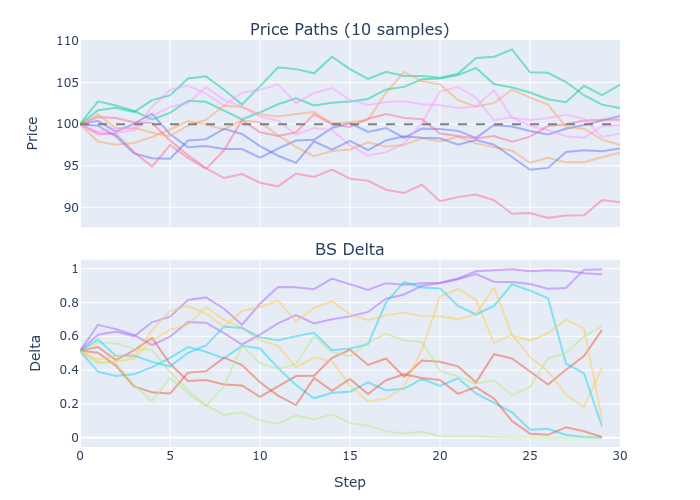

In [9]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=["Price Paths (10 samples)", "BS Delta"],
)

n_show = 10
for i in range(n_show):
    fig.add_trace(
        go.Scatter(
            y=paths[i].cpu().numpy(),
            mode="lines",
            opacity=0.5,
            showlegend=False,
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            y=bs_delta[i],
            mode="lines",
            opacity=0.5,
            showlegend=False,
        ),
        row=2,
        col=1,
    )

fig.add_hline(y=STRIKE, line_dash="dash", line_color="gray", row=1, col=1)
fig.update_yaxes(title_text="Price", row=1, col=1)
fig.update_yaxes(title_text="Delta", row=2, col=1)
fig.update_xaxes(title_text="Step", row=2, col=1)
fig.update_layout(height=500, margin=dict(t=40, b=40))
fig.show()

## Baseline: Black-Scholes Delta Hedging

The classical benchmark: at each step, hold exactly the BS delta. This is the
rule-based hedge — it assumes continuous trading, zero costs, and constant volatility.
Under real-world frictions, delta hedging trades too frequently and incurs unnecessary
transaction costs.

In [10]:
def compute_hedge_pnl(positions, paths, payoff, premium, cost_rate=0.0):
    """Compute terminal PnL for a hedging strategy.

    positions: (n_paths, n_steps) — shares held over each interval
    paths: (n_paths, n_steps + 1) — price paths
    payoff: (n_paths,) — option payoff at maturity
    premium: (n_paths,) — premium received
    cost_rate: proportional transaction cost rate
    """
    price_changes = paths[:, 1:] - paths[:, :-1]
    hedging_gains = (positions * price_changes).sum(dim=1)

    # Transaction costs: |change in position| * price * cost_rate
    position_changes = torch.diff(
        torch.cat(
            [
                torch.zeros(positions.shape[0], 1, device=positions.device, dtype=positions.dtype),
                positions,
            ],
            dim=1,
        ),
        dim=1,
    )
    costs = (cost_rate * position_changes.abs() * paths[:, :-1]).sum(dim=1)

    return premium - payoff + hedging_gains - costs

In [11]:
# Option payoff at maturity
payoff = torch.relu(paths[:, -1] - STRIKE)

# Delta hedge PnL (with and without costs)
pnl_delta_no_cost = compute_hedge_pnl(bs_delta_t, paths, payoff, premium, cost_rate=0.0)
pnl_delta = compute_hedge_pnl(bs_delta_t, paths, payoff, premium, cost_rate=COST_RATE)
pnl_no_hedge = premium - payoff

### Baseline PnL Statistics

In [12]:
def compute_cvar(pnl, alpha=0.05):
    """Sample CVaR (expected shortfall) of losses = -PnL."""
    losses = -pnl
    k = max(int(round(alpha * len(losses))), 1)
    worst, _ = torch.topk(losses, k=k, largest=True)
    return float(worst.mean().item())

These helper summaries keep the reporting comparable across the unhedged, delta-hedged, and
learned strategies.

In [13]:
def pnl_stats(pnl, label=""):
    """Return dict of PnL statistics."""
    return {
        "strategy": label,
        "mean": float(pnl.mean()),
        "std": float(pnl.std()),
        "cvar_95": compute_cvar(pnl, 0.05),
        "cvar_99": compute_cvar(pnl, 0.01),
        "min": float(pnl.min()),
    }

In [14]:
baseline_stats = pl.DataFrame(
    [
        pnl_stats(pnl_no_hedge, "No Hedge"),
        pnl_stats(pnl_delta_no_cost, "Delta (no cost)"),
        pnl_stats(pnl_delta, f"Delta (cost={COST_RATE})"),
    ]
)
baseline_stats

strategy,mean,std,cvar_95,cvar_99,min
str,f64,f64,f64,f64,f64
"""No Hedge""",-0.309518,4.411211,12.935525,17.942281,-35.825144
"""Delta (no cost)""",-0.000102,0.432461,1.010981,1.49242,-3.459799
"""Delta (cost=0.001)""",-0.223047,0.447044,1.313462,1.825973,-3.921833


Delta hedging without costs concentrates PnL near zero. With proportional costs,
the mean shifts negative (costs erode gains) and the tail worsens. This is the gap
the deep hedger aims to close.

## The Deep Hedger

Following Buehler et al. (2019), we parameterize the hedge position at each step as:

$$\delta_k = F_k(I_k, \delta_{k-1})$$

where $I_k$ is the information set (moneyness, time-to-maturity, implied vol, log return)
and $\delta_{k-1}$ is the previous position. Each timestep has its own MLP $F_k$, making
the architecture *semi-recurrent*: positions feed forward, but there is no shared hidden
state or backpropagation through time beyond the position variable.

In [15]:
class DeepHedger(nn.Module):
    """Semi-recurrent deep hedging network (Buehler et al. 2019).

    Each timestep has an independent MLP that maps (info_k, delta_{k-1}) to delta_k.
    """

    def __init__(self, n_steps, n_features, hidden_size=32, max_position=1.5):
        super().__init__()
        self.n_steps = n_steps
        in_dim = n_features + 1  # features + previous position

        self.nets = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(in_dim, hidden_size),
                    nn.ReLU(),
                    nn.Linear(hidden_size, hidden_size),
                    nn.ReLU(),
                    nn.Linear(hidden_size, 1),
                )
                for _ in range(n_steps)
            ]
        )
        self.max_position = max_position

    def forward(self, info):
        """Forward pass.

        info: (batch, n_steps, n_features) — market information at each step
        Returns: (batch, n_steps) — hedge positions
        """
        batch = info.shape[0]
        positions = []
        prev_pos = torch.zeros(batch, 1, device=info.device)

        for k in range(self.n_steps):
            x = torch.cat([info[:, k, :], prev_pos], dim=1)
            pos = self.nets[k](x)
            if self.max_position is not None:
                pos = torch.tanh(pos) * self.max_position
            positions.append(pos)
            prev_pos = pos

        return torch.cat(positions, dim=1)  # (batch, n_steps)

## CVaR as Differentiable Training Objective

In Section 19.3 we defined CVaR as a coherent risk measure for evaluating tail losses.
Now we use it as a *loss function* for training. The key is the Rockafellar-Uryasev
representation:

$$\text{CVaR}_\alpha(L) = \min_w \left[ w + \frac{1}{\alpha} \mathbb{E}\left[(L - w)_+\right] \right]$$

where $L = -PL_T$ are the losses. The threshold $w$ (the VaR level) is a learnable
parameter optimized jointly with the hedger weights — gradient descent finds both the
optimal hedge *and* the optimal VaR estimate simultaneously.

In [16]:
class CVaRLoss(nn.Module):
    """Differentiable CVaR loss via the OCE representation.

    The learnable parameter w converges to the VaR level during training.
    """

    def __init__(self, alpha=0.05):
        super().__init__()
        self.alpha = alpha
        self.w = nn.Parameter(torch.tensor(0.0))

    def forward(self, pnl):
        """Compute CVaR of losses = -pnl."""
        losses = -pnl
        excess = torch.relu(losses - self.w)
        return self.w + excess.mean() / self.alpha

## Prepare Training Data

The information set $I_k$ at each step includes:
- **Log-moneyness**: $\log(S_k / K)$ — where the option is relative to the strike
- **Time-to-maturity**: $\tau_k$ — remaining time (normalized)
- **Implied vol proxy**: constant $\sigma$ under GBM (real data would use market IV)
- **Log return**: $\log(S_k / S_{k-1})$ — recent price move

In [17]:
def prepare_info(paths, strike, sigma, n_steps, dt):
    """Build the information tensor for the deep hedger.

    Returns tensor of shape (n_paths, n_steps, 4).
    """
    spot = paths[:, :-1]  # (n_paths, n_steps)

    log_moneyness = torch.log(spot / strike)
    tau = (
        torch.tensor(
            [(n_steps - k) * dt for k in range(n_steps)], device=paths.device, dtype=paths.dtype
        )
        .unsqueeze(0)
        .expand(spot.shape[0], -1)
    )
    vol = torch.full_like(spot, sigma)
    log_ret = torch.zeros_like(spot)
    log_ret[:, 1:] = torch.log(paths[:, 1:-1] / paths[:, :-2])

    return torch.stack([log_moneyness, tau, vol, log_ret], dim=2).float()

In [18]:
info = prepare_info(paths, STRIKE, SIGMA, N_STEPS, DT)
print(f"Information tensor: {tuple(info.shape)} — [log_moneyness, tau, vol, log_return]")

Information tensor: (50000, 30, 4) — [log_moneyness, tau, vol, log_return]


Split into training and validation sets.

In [19]:
n_train = int(0.8 * N_PATHS)
train_idx = slice(0, n_train)
val_idx = slice(n_train, N_PATHS)

info_train, info_val = info[train_idx], info[val_idx]
paths_train, paths_val = paths[train_idx], paths[val_idx]
payoff_train, payoff_val = payoff[train_idx], payoff[val_idx]
premium_train, premium_val = premium[train_idx], premium[val_idx]

print(f"Train: {n_train:,} paths | Val: {N_PATHS - n_train:,} paths")

Train: 40,000 paths | Val: 10,000 paths


## Training

We train with Adam, using mini-batches of simulated scenarios. Each forward pass
computes positions, PnL (including costs), and the CVaR loss. Gradient clipping
prevents instability from extreme tail scenarios.

In [20]:
N_FEATURES = info.shape[2]
cache_config = {
    "n_paths": N_PATHS,
    "n_steps": N_STEPS,
    "s0": S0,
    "strike": STRIKE,
    "mu": MU,
    "sigma": SIGMA,
    "r": R,
    "dt": DT,
    "cost_rate": COST_RATE,
    "cvar_alpha": CVAR_ALPHA,
    "hidden_size": HIDDEN_SIZE,
    "n_epochs": N_EPOCHS,
    "lr": LR,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "cost_sweep_epochs": COST_SWEEP_EPOCHS,
    "cost_sweep_max_train_paths": COST_SWEEP_MAX_TRAIN_PATHS,
}

In [21]:
cache_loaded = False
train_losses = []
val_losses = []
cost_results = []

Cached artifacts let the notebook reuse a previous training run when
the configuration is unchanged — `train_losses`, `val_losses`,
`deep_positions`, and per-cost validation tensors. The cache restores
*rendered* artifacts only: model weights are **not** persisted, so a
cache hit does not continue training. Force a fresh fit by setting
`FORCE_RETRAIN = True`.

In [22]:
if CACHE_NPZ.exists() and CACHE_JSON.exists() and not FORCE_RETRAIN:
    try:
        cached_config = json.loads(CACHE_JSON.read_text())
        if cached_config == cache_config:
            cached = np.load(CACHE_NPZ, allow_pickle=True)
            train_losses = cached["train_losses"].tolist()
            val_losses = cached["val_losses"].tolist()
            deep_positions = torch.tensor(cached["deep_positions"], device=device)
            pnl_deep = torch.tensor(cached["pnl_deep"], device=device)
            pnl_delta_val = torch.tensor(cached["pnl_delta_val"], device=device)
            pnl_no_hedge_val = torch.tensor(cached["pnl_no_hedge_val"], device=device)
            costs = cached["costs"].tolist()
            delta_cvars = cached["delta_cvars"].tolist()
            deep_cvars = cached["deep_cvars"].tolist()
            deep_trades = cached["deep_trades"].tolist()
            cost_results = [
                {
                    "cost": float(cost),
                    "delta_cvar": float(delta_cvar),
                    "deep_cvar": float(deep_cvar),
                    "deep_mean_trades": float(trades),
                }
                for cost, delta_cvar, deep_cvar, trades in zip(
                    costs, delta_cvars, deep_cvars, deep_trades, strict=False
                )
            ]
            cache_loaded = True
            print(f"Loaded cached deep-hedging artifacts: {CACHE_NPZ.name}")
    except Exception as exc:
        print(f"Cache load failed, retraining: {exc}")

Loaded cached deep-hedging artifacts: deep_hedging_cache_v2.npz


In [23]:
model = DeepHedger(N_STEPS, N_FEATURES, hidden_size=HIDDEN_SIZE).to(device)
criterion = CVaRLoss(alpha=CVAR_ALPHA).to(device)
optimizer = torch.optim.Adam(list(model.parameters()) + list(criterion.parameters()), lr=LR)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Architecture: {N_STEPS} MLPs, each ({N_FEATURES}+1) -> {HIDDEN_SIZE} -> {HIDDEN_SIZE} -> 1")

Model parameters: 38,430
Architecture: 30 MLPs, each (4+1) -> 32 -> 32 -> 1


In [24]:
if not cache_loaded:
    for epoch in range(N_EPOCHS):
        model.train()
        # Shuffle training data
        perm = torch.randperm(n_train, device=device)

        epoch_loss = 0.0
        n_batches = 0

        for start in range(0, n_train, BATCH_SIZE):
            idx = perm[start : start + BATCH_SIZE]

            positions = model(info_train[idx])
            pnl = compute_hedge_pnl(
                positions, paths_train[idx], payoff_train[idx], premium_train[idx], COST_RATE
            )
            loss = criterion(pnl)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        train_losses.append(epoch_loss / n_batches)

        # Validation
        model.eval()
        with torch.no_grad():
            val_pos = model(info_val)
            val_pnl = compute_hedge_pnl(val_pos, paths_val, payoff_val, premium_val, COST_RATE)
            val_loss = criterion(val_pnl).item()
        val_losses.append(val_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1:3d}/{N_EPOCHS} | Train CVaR: {train_losses[-1]:.4f} | "
                f"Val CVaR: {val_loss:.4f}"
            )
else:
    print(f"Skipped deep-hedging retraining (cache hit): {CACHE_NPZ.name}")

Skipped deep-hedging retraining (cache hit): deep_hedging_cache_v2.npz


### Learning Curves

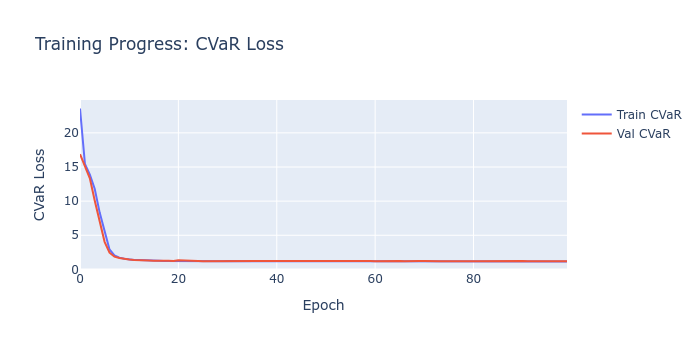

In [25]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=train_losses, name="Train CVaR", mode="lines"))
fig.add_trace(go.Scatter(y=val_losses, name="Val CVaR", mode="lines"))
fig.update_layout(
    title="Training Progress: CVaR Loss",
    xaxis_title="Epoch",
    yaxis_title="CVaR Loss",
    height=350,
)
fig.show()

## Results: Three-Way Comparison

We compare three strategies on the validation set:
1. **No hedge**: naked short option (maximum tail risk)
2. **Delta hedge**: hold BS delta at each step (rule-based)
3. **Deep hedge**: learned positions minimizing CVaR

In [26]:
if not cache_loaded:
    model.eval()
    with torch.no_grad():
        deep_positions = model(info_val)
        pnl_deep = compute_hedge_pnl(deep_positions, paths_val, payoff_val, premium_val, COST_RATE)

    pnl_delta_val = compute_hedge_pnl(
        bs_delta_t[val_idx], paths_val, payoff_val, premium_val, COST_RATE
    )
    pnl_no_hedge_val = premium_val - payoff_val

### PnL Distributions

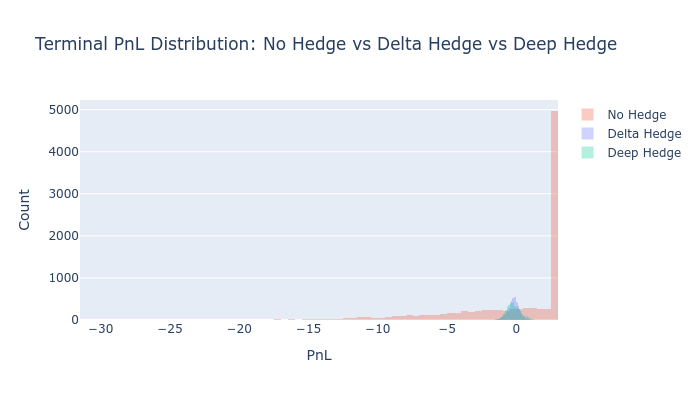

In [27]:
fig = go.Figure()

for pnl_data, name, color in [
    (pnl_no_hedge_val, "No Hedge", "rgba(239,85,59,0.5)"),
    (pnl_delta_val, "Delta Hedge", "rgba(99,110,250,0.5)"),
    (pnl_deep, "Deep Hedge", "rgba(0,204,150,0.5)"),
]:
    fig.add_trace(
        go.Histogram(
            x=pnl_data.cpu().numpy(),
            name=name,
            opacity=0.6,
            nbinsx=100,
            marker_color=color,
        )
    )

fig.update_layout(
    title="Terminal PnL Distribution: No Hedge vs Delta Hedge vs Deep Hedge",
    xaxis_title="PnL",
    yaxis_title="Count",
    barmode="overlay",
    height=400,
)
fig.show()

### Comparison Table

In [28]:
results = [
    pnl_stats(pnl_no_hedge_val, "No Hedge"),
    pnl_stats(pnl_delta_val, f"Delta Hedge (cost={COST_RATE})"),
    pnl_stats(pnl_deep, f"Deep Hedge (cost={COST_RATE})"),
]
results_df = pl.DataFrame(results)
results_df

strategy,mean,std,cvar_95,cvar_99,min
str,f64,f64,f64,f64,f64
"""No Hedge""",-0.354412,4.472304,13.16036,17.800276,-31.086428
"""Delta Hedge (cost=0.001)""",-0.225039,0.448996,1.324744,1.863985,-2.933002
"""Deep Hedge (cost=0.001)""",-0.199415,0.521669,1.184309,1.5113,-2.294177


The deep hedger achieves a tighter PnL distribution and lower tail risk (CVaR) than
delta hedging under the same transaction costs. It sacrifices a small amount of mean PnL
to compress the left tail — exactly the trade-off CVaR optimization encodes.

## What the Hedger Learned

The most instructive analysis is comparing the learned positions to the BS delta
benchmark path-by-path. If the network simply replicates delta hedging, the exercise
is pointless. The interesting question is: *where does it deviate, and why?*

In [29]:
n_examples = 5

In [30]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=["Price Paths", "Positions: Deep Hedge vs BS Delta"],
)

In [31]:
for i in range(n_examples):
    path_i = paths_val[i].cpu().numpy()
    deep_i = deep_positions[i].cpu().numpy()
    delta_i = bs_delta_t[val_idx][i].cpu().numpy()

    fig.add_trace(
        go.Scatter(y=path_i, mode="lines", opacity=0.5, showlegend=False),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            y=deep_i,
            mode="lines",
            name=f"Deep #{i}" if i == 0 else None,
            line=dict(color="green"),
            opacity=0.5,
            showlegend=(i == 0),
        ),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            y=delta_i,
            mode="lines",
            name=f"BS Delta #{i}" if i == 0 else None,
            line=dict(color="blue", dash="dot"),
            opacity=0.5,
            showlegend=(i == 0),
        ),
        row=2,
        col=1,
    )

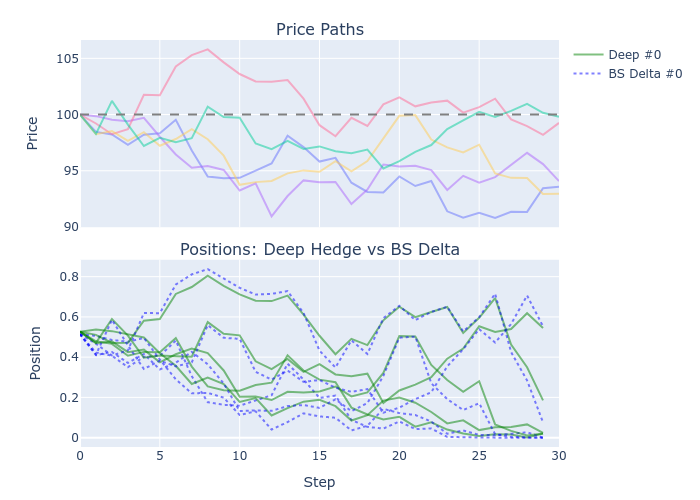

In [32]:
fig.add_hline(y=STRIKE, line_dash="dash", line_color="gray", row=1, col=1)
fig.update_yaxes(title_text="Price", row=1, col=1)
fig.update_yaxes(title_text="Position", row=2, col=1)
fig.update_xaxes(title_text="Step", row=2, col=1)
fig.update_layout(height=500, margin=dict(t=40, b=40))
fig.show()

### No-Transaction Bands

A common theoretical expectation is that transaction costs should create implicit
no-transaction bands: when the BS delta changes only slightly, an optimal hedge may
prefer to hold its current position rather than rebalance. This is analogous to the
Whalley-Wilmott (1997) asymptotic result, which shows that the optimal hedge under
proportional costs is to hold the current position unless it deviates from the BS
delta by more than a threshold proportional to $(\text{cost})^{1/3}$.

The figure above lets us test whether this particular trained network shows that
behavior on the cached validation sample.

In [33]:
# Compare trading activity: number of "significant" trades
deep_changes = torch.diff(
    torch.cat([torch.zeros(deep_positions.shape[0], 1, device=device), deep_positions], dim=1),
    dim=1,
).abs()
delta_changes = torch.diff(
    torch.cat(
        [torch.zeros(bs_delta_t[val_idx].shape[0], 1, device=device), bs_delta_t[val_idx]], dim=1
    ),
    dim=1,
).abs()

threshold = 0.01  # minimum trade size to count
deep_trades = (deep_changes > threshold).float().sum(dim=1)
delta_trades = (delta_changes > threshold).float().sum(dim=1)

print(f"Mean trades per path (|change| > {threshold}):")
print(f"  Delta hedge: {delta_trades.mean():.1f}")
print(f"  Deep hedge:  {deep_trades.mean():.1f}")
print(f"  Reduction:   {(1 - deep_trades.mean() / delta_trades.mean()) * 100:.1f}%")

Mean trades per path (|change| > 0.01):
  Delta hedge: 24.1
  Deep hedge:  26.0
  Reduction:   -8.1%


Mean significant trades per path are slightly *higher* for the deep hedger (26.0) than
for the delta hedge (24.1). Whalley-Wilmott no-transaction bands only emerge cleanly
with much longer training, larger costs, or an explicit trade-count regularizer; under
these settings the network learned a different position profile that improves CVaR on
this sample without trading less often.

## Transaction Cost Sensitivity

How does the advantage of learned hedging change as costs increase? We train separate
models at different cost levels and compare CVaR.

In [34]:
if not cache_loaded:
    cost_levels = [0.0, 0.0001, 0.0005, 0.001, 0.005]
    sweep_n_train = min(COST_SWEEP_MAX_TRAIN_PATHS, n_train)
    info_sweep = info_train[:sweep_n_train]
    paths_sweep = paths_train[:sweep_n_train]
    payoff_sweep = payoff_train[:sweep_n_train]
    premium_sweep = premium_train[:sweep_n_train]
    print(
        f"Cost sweep training: {sweep_n_train:,} paths, {COST_SWEEP_EPOCHS} epochs per cost level"
    )

`_train_cost_level(cost)` is the inner loop for the cost sweep below:
it trains one fresh deep hedger at a single transaction-cost rate and
evaluates the resulting CVaR against the Black–Scholes delta baseline
at the same cost. The sweep calls this helper for each entry in
`cost_levels` so each panel of Figure 19.7 corresponds to a separately
trained policy, not a single model evaluated at multiple costs.

In [35]:
def _train_cost_level(cost):
    """Train a deep hedger at one cost level and evaluate against delta hedging."""
    m = DeepHedger(N_STEPS, N_FEATURES, hidden_size=HIDDEN_SIZE).to(device)
    c = CVaRLoss(alpha=CVAR_ALPHA).to(device)
    opt = torch.optim.Adam(list(m.parameters()) + list(c.parameters()), lr=LR)

    m.train()
    for epoch in range(COST_SWEEP_EPOCHS):
        perm = torch.randperm(sweep_n_train, device=device)
        for start in range(0, sweep_n_train, BATCH_SIZE):
            idx = perm[start : start + BATCH_SIZE]
            pos = m(info_sweep[idx])
            pnl = compute_hedge_pnl(
                pos, paths_sweep[idx], payoff_sweep[idx], premium_sweep[idx], cost
            )
            loss = c(pnl)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=5.0)
            opt.step()

    m.eval()
    with torch.no_grad():
        deep_pos = m(info_val)
        pnl_d = compute_hedge_pnl(deep_pos, paths_val, payoff_val, premium_val, cost)

    pnl_b = compute_hedge_pnl(bs_delta_t[val_idx], paths_val, payoff_val, premium_val, cost)

    deep_trades_c = (
        torch.diff(
            torch.cat([torch.zeros(deep_pos.shape[0], 1, device=device), deep_pos], dim=1),
            dim=1,
        )
        .abs()
        .gt(0.01)
        .float()
        .sum(dim=1)
        .mean()
        .item()
    )
    return {
        "cost": cost,
        "delta_cvar": compute_cvar(pnl_b, CVAR_ALPHA),
        "deep_cvar": compute_cvar(pnl_d, CVAR_ALPHA),
        "deep_mean_trades": deep_trades_c,
    }

In [36]:
if not cache_loaded:
    for cost in cost_levels:
        result = _train_cost_level(cost)
        cost_results.append(result)
        print(
            f"Cost={cost:.4f} | Delta CVaR: {result['delta_cvar']:.4f} | "
            f"Deep CVaR: {result['deep_cvar']:.4f} | "
            f"Deep trades: {result['deep_mean_trades']:.1f}"
        )
else:
    print(f"Skipped cost-sensitivity retraining (cache hit): {CACHE_NPZ.name}")

Skipped cost-sensitivity retraining (cache hit): deep_hedging_cache_v2.npz


### CVaR vs Transaction Cost Level

In [37]:
if not cache_loaded:
    np.savez(
        CACHE_NPZ,
        train_losses=np.array(train_losses, dtype=np.float32),
        val_losses=np.array(val_losses, dtype=np.float32),
        deep_positions=deep_positions.detach().cpu().numpy().astype(np.float32),
        pnl_deep=pnl_deep.detach().cpu().numpy().astype(np.float32),
        pnl_delta_val=pnl_delta_val.detach().cpu().numpy().astype(np.float32),
        pnl_no_hedge_val=pnl_no_hedge_val.detach().cpu().numpy().astype(np.float32),
        costs=np.array([r["cost"] for r in cost_results], dtype=np.float32),
        delta_cvars=np.array([r["delta_cvar"] for r in cost_results], dtype=np.float32),
        deep_cvars=np.array([r["deep_cvar"] for r in cost_results], dtype=np.float32),
        deep_trades=np.array([r["deep_mean_trades"] for r in cost_results], dtype=np.float32),
    )
    CACHE_JSON.write_text(json.dumps(cache_config, indent=2, sort_keys=True))
    print(f"Saved deep-hedging cache artifacts: {CACHE_NPZ.name}")

In [38]:
costs_arr = [r["cost"] for r in cost_results]
delta_cvars = [r["delta_cvar"] for r in cost_results]
deep_cvars = [r["deep_cvar"] for r in cost_results]

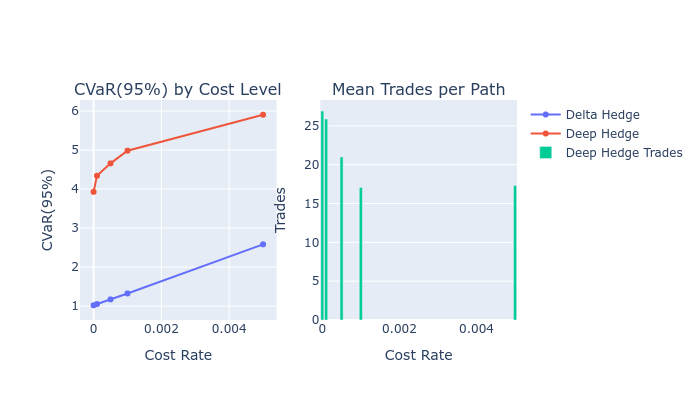

In [39]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["CVaR(95%) by Cost Level", "Mean Trades per Path"],
)

fig.add_trace(
    go.Scatter(x=costs_arr, y=delta_cvars, name="Delta Hedge", mode="lines+markers"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=costs_arr, y=deep_cvars, name="Deep Hedge", mode="lines+markers"),
    row=1,
    col=1,
)

fig.add_trace(
    go.Bar(
        x=costs_arr,
        y=[r["deep_mean_trades"] for r in cost_results],
        name="Deep Hedge Trades",
    ),
    row=1,
    col=2,
)

fig.update_xaxes(title_text="Cost Rate", row=1, col=1)
fig.update_xaxes(title_text="Cost Rate", row=1, col=2)
fig.update_yaxes(title_text="CVaR(95%)", row=1, col=1)
fig.update_yaxes(title_text="Trades", row=1, col=2)
fig.update_layout(height=400)
fig.show()

Read the CVaR panel with the training budget in mind. To keep the sweep fast, each
point trains a *separate, deliberately lightweight* hedger — COST_SWEEP_EPOCHS epochs
on a capped path budget — so these models are far from converged. Unlike the fully
trained hedger above (which edges out delta hedging on CVaR), the sweep hedgers sit
well above delta at every cost level: CVaR(95%) of roughly 3.9-5.9 versus the delta
hedge's 1.0-2.6. That gap reflects the reduced training budget, not a property of deep
hedging. What the sweep *does* show robustly is policy adaptation to costs: as frictions
rise, the learned policy trades less, from about 27 significant trades per path at zero
cost down to roughly 17 at the highest cost. The robust takeaway is that the objective
makes the policy cost-aware — not a CVaR ranking from these under-trained sweep models.

This connects directly to Chapter 18 (Transaction Costs): costs shape optimal behavior.
A cost-aware hedger is fundamentally different from a cost-naive hedger that is simply
penalized after the fact.

### Deployment Notes

Three implementation patterns matter when wrapping a learned hedger
into a production envelope: (1) log every input feature alongside the
emitted position so each trade is reconstructible from the audit
trail; (2) validate walk-forward — fit on a closed historical window,
evaluate on a strictly later one; refit only after drift detection
(see `07_drift_detection`) signals a regime shift; (3) deploy the
learned policy *inside* hard limits — fixed stop losses, exposure
caps, daily-loss kill switches — so a model failure cannot exit those
bounds. The wider governance discussion (interpretability,
model-risk register, validation cadence) lives in book §19.8.

In [40]:
print(f"Paths: {N_PATHS:,} | Steps: {N_STEPS} | Cost rate: {COST_RATE}")
print(f"Training epochs: {N_EPOCHS} | Model params: {sum(p.numel() for p in model.parameters()):,}")

Paths: 50,000 | Steps: 30 | Cost rate: 0.001
Training epochs: 100 | Model params: 38,430


In [41]:
results_df.select(["strategy", "mean", "cvar_95"])

strategy,mean,cvar_95
str,f64,f64
"""No Hedge""",-0.354412,13.16036
"""Delta Hedge (cost=0.001)""",-0.225039,1.324744
"""Deep Hedge (cost=0.001)""",-0.199415,1.184309


## Key Takeaways

| Aspect | Rule-Based (Delta Hedge) | Learned (Deep Hedge) |
|--------|--------------------------|----------------------|
| **Objective** | Replicate option delta | Minimize CVaR of PnL |
| **Cost awareness** | None (trades every step) | Cost term enters the loss directly |
| **Adaptiveness** | Fixed formula | Conditioned on path state |
| **Interpretability** | Fully transparent | Requires post-hoc tools |
| **Model risk** | Assumes BS model | Assumes training distribution |
| **Best for** | Low-cost, liquid markets | Tail-objective hedging under frictions |

1. **CVaR is both a metric and a training objective.** Section 19.3
   defined it for measurement; here we optimised it directly, closing
   the loop between risk quantification and risk control.
2. **CVaR reduction does not imply fewer trades.** At $\text{cost}=0.001$
   the learned hedger lowers validation CVaR(95%) from $1.32$ (delta) to
   $1.18$ while taking *more* significant rebalances per path ($26.0$
   vs $24.1$). The Buehler-style objective rewards tail-risk reduction
   in PnL units, not trading parsimony; no-transaction bands only
   emerge cleanly with much longer training, harder cost regimes, or
   explicit trade-count regularisation.
3. **Learned controls complement rules.** The safest deployment is
   hybrid — learned policies inside hard limits set by traditional
   controls.
4. **The bridge to RL.** Deep hedging is a special case of policy
   optimisation; Chapter 20 generalises this to multi-step MDPs,
   actor-critic methods, and real data.

**Next**: [`10_ml4t_backtest_risk_demo`](10_ml4t_backtest_risk_demo.ipynb)
documents how the `ml4t.backtest.risk` envelope wraps learned and
rule-based policies for production integration.